In [12]:
#Configuration
import osmnx as ox
import geopandas as gpd
import pandas as pd

BASE = "/home/jovyan/work/children15mc"
RAW = f"{BASE}/data/raw"
PROC = f"{BASE}/data/processed"
FIG = f"{BASE}/outputs/figures"

ox.settings.use_cache = True
ox.settings.cache_folder = f"{BASE}/cache"

lsoa = gpd.read_file(f"{PROC}/lsoa_london.gpkg")
london_area = lsoa.union_all()
print("Configuration complete.")

Configuration complete.


In [13]:
#1. School: Filter out the primary schools
sch = pd.read_csv(f"{RAW}/schools_england.csv", encoding="latin1")
sch = sch[
    (sch["PhaseOfEducation (name)"] == "Primary") &
    (sch["EstablishmentStatus (name)"] == "Open") &
    (sch["Easting"].notna())
].copy()
schools = gpd.GeoDataFrame(
    sch, geometry=gpd.points_from_xy(sch["Easting"], sch["Northing"]), crs=27700)
print(f"English primary school(Open): {len(schools)}")

lsoa = gpd.read_file(f"{PROC}/lsoa_london.gpkg")
london_area = lsoa.union_all()
schools = schools[schools.within(london_area)].copy()
print(f"London Primary School: {len(schools)}")

schools[["EstablishmentName", "geometry"]].to_file(
    f"{PROC}/schools_london.gpkg", driver="GPKG")
print("School saved")

/tmp/ipykernel_241489/1800977899.py:2: DtypeWarning: Columns (48,51,69,70,71,124,129,134) have mixed types. Specify dtype option on import or set low_memory=False.
  sch = pd.read_csv(f"{RAW}/schools_england.csv", encoding="latin1")


English primary school(Open): 16669
London Primary School: 1752
School saved


In [14]:
#2. Parks: Fetch parks from OSM
ox.settings.use_cache = True
ox.settings.cache_folder = f"{BASE}/cache"

# Extract parks within the London area
london_4326 = gpd.GeoSeries([london_area], crs=27700).to_crs(4326).iloc[0]
parks = ox.features_from_polygon(london_4326, tags={"leisure": "park"})
parks = parks.to_crs(27700)

# Determine the centroid of the park
parks_pt = parks.copy()
parks_pt["geometry"] = parks_pt.geometry.centroid
parks_pt = parks_pt[parks_pt.geometry.notna()][["geometry"]]
print(f"London Parks: {len(parks_pt)}")

parks_pt.to_file(f"{PROC}/parks_london.gpkg", driver="GPKG")
print("Park saved")

London Parks: 3251
Park saved


In [15]:
# 3. Calculate Child 15mC Score
iso = gpd.read_file(f"{PROC}/isochrones_all.gpkg")
schools = gpd.read_file(f"{PROC}/schools_london.gpkg")
parks = gpd.read_file(f"{PROC}/parks_london.gpkg")

print(f"Isochrone {len(iso)}, School {len(schools)}, Park {len(parks)}")

# Use a spatial join to count the number of facilities within each isochrone
def count_within(iso, facilities, name):
    joined = gpd.sjoin(facilities, iso, how="inner", predicate="within")
    counts = joined.groupby("lsoa21cd").size().rename(name)
    return counts

n_schools = count_within(iso, schools, "n_schools")
n_parks   = count_within(iso, parks, "n_parks")

# Merge
iso = iso.merge(n_schools, on="lsoa21cd", how="left")
iso = iso.merge(n_parks, on="lsoa21cd", how="left")
iso["n_schools"] = iso["n_schools"].fillna(0).astype(int)
iso["n_parks"]   = iso["n_parks"].fillna(0).astype(int)

# Child 15mC Score = Park + School
iso["c15mc_score"] = iso["n_schools"] + iso["n_parks"]

print("Accessibility Score Statistics")
print(iso[["n_schools", "n_parks", "c15mc_score"]].describe())

Isochrone 4659, School 1752, Park 3251
Accessibility Score Statistics
         n_schools      n_parks  c15mc_score
count  4659.000000  4659.000000  4659.000000
mean      2.215068     3.792230     6.007298
std       1.600001     4.361038     5.271661
min       0.000000     0.000000     0.000000
25%       1.000000     1.000000     3.000000
50%       2.000000     2.000000     5.000000
75%       3.000000     5.000000     8.000000
max      10.000000    34.000000    39.000000


In [16]:
#4. Merge scores back into the main analysis table
df = gpd.read_file(f"{PROC}/analysis_table.gpkg")
scores = iso[["lsoa21cd", "n_schools", "n_parks", "c15mc_score"]]
df = df.merge(scores, on="lsoa21cd", how="left")

for c in ["n_schools", "n_parks", "c15mc_score"]:
    df[c] = df[c].fillna(0).astype(int)

df.to_file(f"{PROC}/accessibility.gpkg", driver="GPKG")
print(df[["lsoa21cd","lad22nm","idaci_score","c15mc_score"]].head())

    lsoa21cd               lad22nm  idaci_score  c15mc_score
0  E01000011  Barking and Dagenham        0.189            5
1  E01000046  Barking and Dagenham        0.208            3
2  E01000051  Barking and Dagenham        0.322           13
3  E01000077  Barking and Dagenham        0.294            3
4  E01000083  Barking and Dagenham        0.249            4


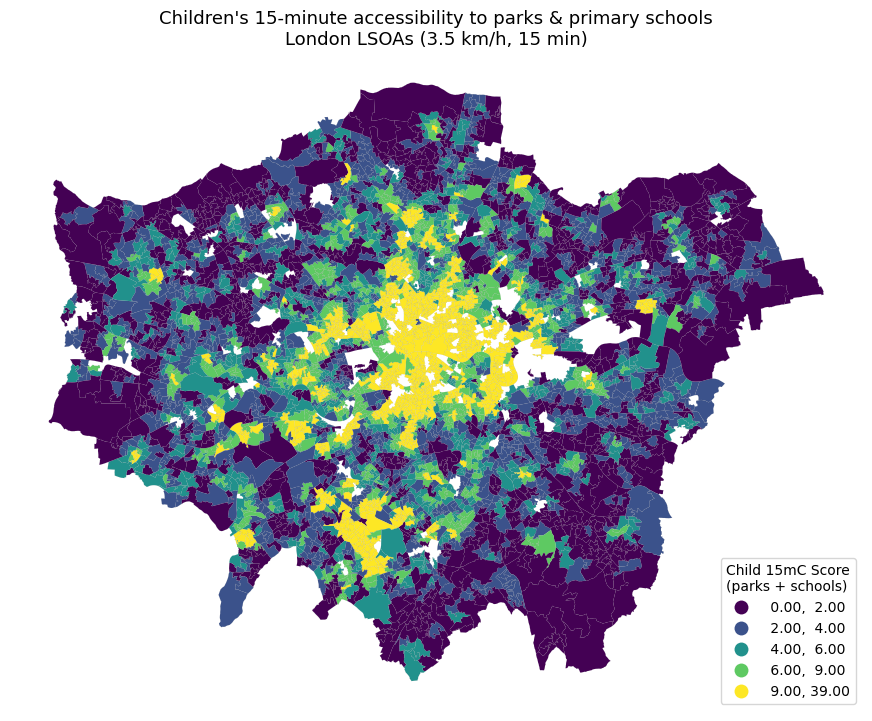

In [17]:
#5. City accessibility map
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 11))
df.plot(column="c15mc_score", cmap="viridis", legend=True,
        scheme="quantiles", k=5, linewidth=0.05, edgecolor="gray", ax=ax,
        legend_kwds={"title": "Child 15mC Score\n(parks + schools)", "loc": "lower right"})
ax.set_title("Children's 15-minute accessibility to parks & primary schools\nLondon LSOAs (3.5 km/h, 15 min)", fontsize=13)
ax.set_axis_off()
plt.savefig(f"{FIG}/accessibility_map.png", dpi=150, bbox_inches="tight")
plt.show()